In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

Observation:

The dataset contains 891 passenger records and 12 features.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Observation:

The dataset contains numerical and categorical features.
Some columns contain missing values that require preprocessing.

In [6]:
-df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Observation:

The Age, Cabin, and Embarked columns contain missing values.
Cabin has the highest number of missing entries.

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observation:

The average passenger age is around 29 years.

The average fare is approximately 32.

A few passengers paid significantly higher fares, indicating the presence of outliers.

In [8]:
df.duplicated().sum()

np.int64(0)

Observation:

No duplicate records were found in the dataset.

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Observation:

Missing values were successfully handled.

The Cabin column was removed due to excessive missing data.

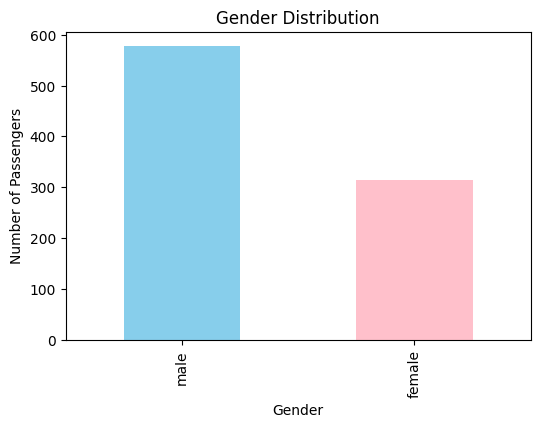

In [13]:
plt.figure(figsize=(6,4))

df['Sex'].value_counts().plot(kind='bar', color=['skyblue','pink'])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Male passengers were significantly higher than female passengers.
- Around 577 passengers were male, while 314 were female.

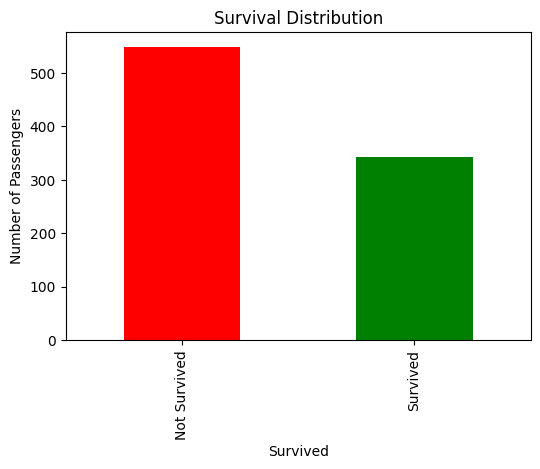

In [14]:
plt.figure(figsize=(6,4))

df['Survived'].value_counts().plot(kind='bar', color=['red','green'])

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.xticks([0,1],["Not Survived","Survived"])

plt.show()

### Observation

- More passengers died than survived.
- Only 342 passengers survived out of 891.

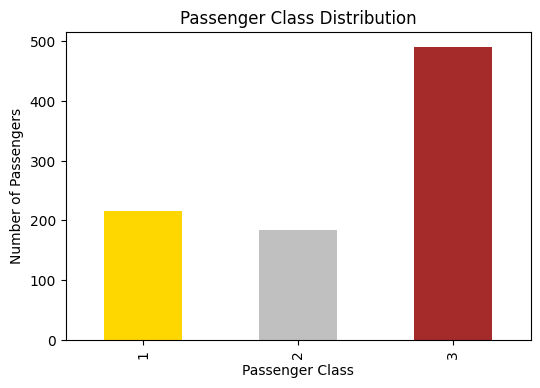

In [15]:
plt.figure(figsize=(6,4))

df['Pclass'].value_counts().sort_index().plot(
    kind='bar',
    color=['gold','silver','brown']
)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Most passengers belonged to the Third Class.
- First Class had the fewest passengers.

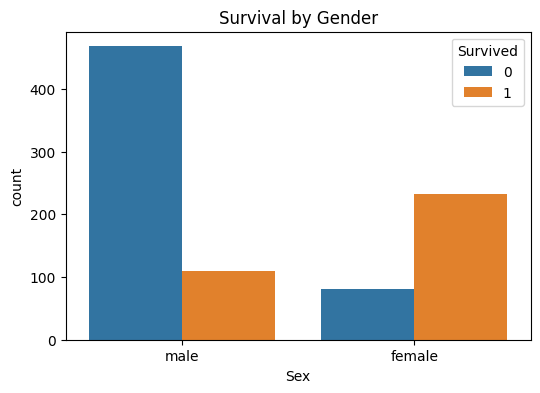

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

### Observation

- Female passengers had a much higher survival rate than male passengers.
- Gender played an important role in survival.

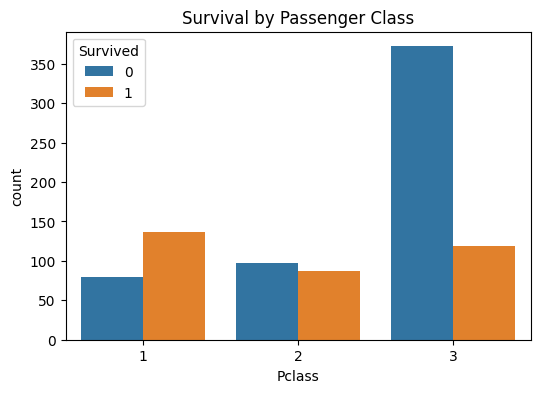

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

### Observation

- First Class passengers had the highest survival rate.
- Third Class passengers had the highest number of deaths.

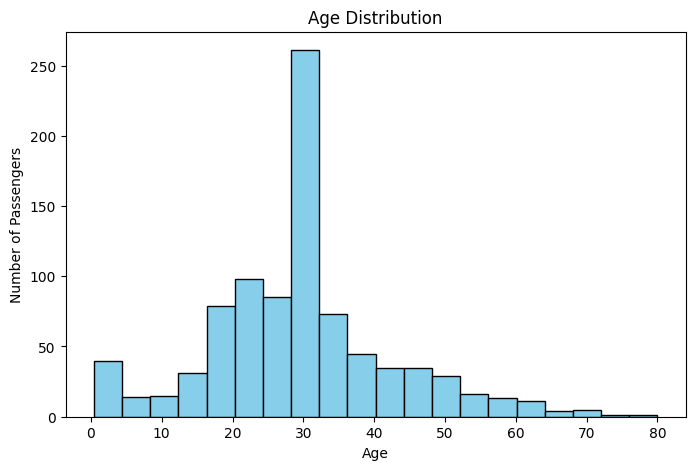

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Most passengers were between 20 and 40 years old.
- Very few passengers were children or elderly.

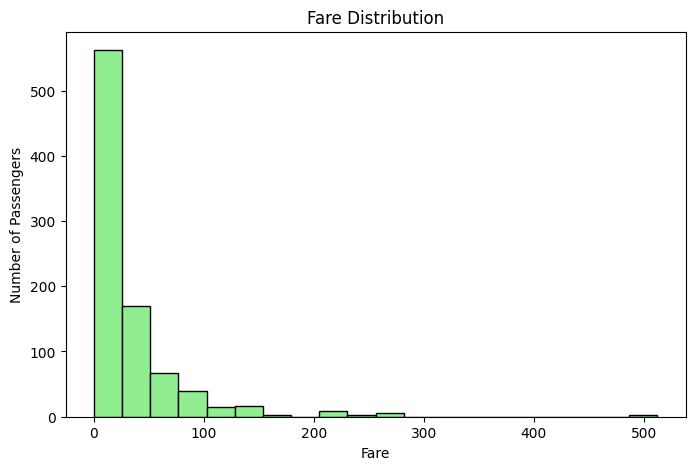

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df['Fare'], bins=20, color='lightgreen', edgecolor='black')

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Most passengers paid relatively low fares.
- A small number of passengers paid very high fares, indicating outliers.

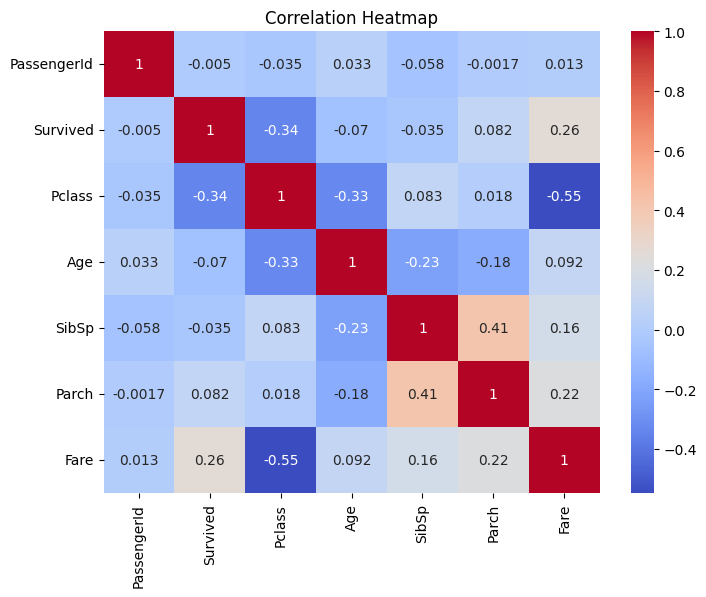

In [20]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Fare shows a positive relationship with survival.
- Passenger Class has a negative relationship with Fare.
- Age has a weak correlation with survival.

## Statistical Summary

The dataset contains 891 passenger records.

The average passenger age is approximately 29 years.

The average fare is around 32.

The maximum fare paid was over 512.

The dataset initially contained missing values, which were cleaned before analysis.

# Exploratory Data Analysis Report

## Objective

The objective of this project was to analyze the Titanic dataset, identify patterns, understand relationships between variables, and extract meaningful insights using statistical summaries and visualizations.

---

## Key Findings

- Most passengers were male.
- Female passengers had a significantly higher survival rate.
- Third Class had the highest number of passengers.
- First Class passengers showed the highest survival rate.
- Most passengers were between 20 and 40 years old.
- Most passengers paid relatively low fares.
- Fare had a positive relationship with survival.
- Age showed only a weak relationship with survival.

---

## Conclusion

The Exploratory Data Analysis successfully identified important trends and patterns within the Titanic dataset. These insights help understand passenger demographics, survival behavior, and the relationships between different features. Such analysis is an essential step before building Machine Learning models.